<a href="https://colab.research.google.com/github/icunicn/UAS/blob/main/Data_Analysis_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
DATA_SOURCE_MAPPING = 'fifa-21-complete-player-dataset:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F905963%2F1537574%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20260409%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20260409T183324Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D3c9a5c76dd40cd27c3d17520497191b9e41c1a415b613964eccc03b8145b7b3f8c3c4cbae4ce583d41b84b8bfbbf03766a7362d2041587aa1a2b971344dc84cf8f5e6a1c918255497e6fbdf120cc1797df35554171b1bcb2e80d203205273a2429f6f2ee86e0ac3d0ee3d57ae265506c27905381d54256de4c3f6a247d3718a62f3f5bdb1ad36d3a09c205812531f3f909a42564b5eb891f67eaf2864c3df484fe765db81662ab9265a39702392ccb2afcd5c95c12af8a50b86efcf1f17677599fcf1cf3ea44de2b30b76f46377a4bfbb4719a1a028a7e44de90dcb04073729dfdabc99419c7ba1616fea189ef7d51f3de12c6f819debc1bb38c6ffac768596c'

KAGGLE_INPUT_PATH = '/kaggle/input'
KAGGLE_WORKING_PATH = '/kaggle/working'

system(paste0('sudo umount ', '/kaggle/input'))
system(paste0('sudo rmdir ', '/kaggle/input'))
system(paste0('sudo mkdir -p -- ', KAGGLE_INPUT_PATH), intern=TRUE)
system(paste0('sudo chmod 777 ', KAGGLE_INPUT_PATH), intern=TRUE)
system(
  paste0('sudo ln -sfn ', KAGGLE_INPUT_PATH,' ',file.path('..', 'input')),
  intern=TRUE)

system(paste0('sudo mkdir -p -- ', KAGGLE_WORKING_PATH), intern=TRUE)
system(paste0('sudo chmod 777 ', KAGGLE_WORKING_PATH), intern=TRUE)
system(
  paste0('sudo ln -sfn ', KAGGLE_WORKING_PATH, ' ', file.path('..', 'working')),
  intern=TRUE)

data_source_mappings = strsplit(DATA_SOURCE_MAPPING, ',')[[1]]
for (data_source_mapping in data_source_mappings) {
    path_and_url = strsplit(data_source_mapping, ':')
    directory = path_and_url[[1]][1]
    download_url = URLdecode(path_and_url[[1]][2])
    filename = sub("\\?.+", "", download_url)
    destination_path = file.path(KAGGLE_INPUT_PATH, directory)
    print(paste0('Mengunduh dan mengompres: ', directory))
    if (endsWith(filename, '.zip')){
      temp = tempfile(fileext = '.zip')
      download.file(download_url, temp)
      unzip(temp, overwrite = TRUE, exdir = destination_path)
      unlink(temp)
    }
    else{
      temp = tempfile(fileext = '.tar')
      download.file(download_url, temp)
      untar(temp, exdir = destination_path)
      unlink(temp)
    }
    print(paste0('Berhasil mengunduh dan mengompres: ', directory))
}

print(paste0('Impor sumber data selesai'))

character(0)

character(0)

character(0)

character(0)

character(0)

character(0)

[1] "Downloading and uncompressing: fifa-21-complete-player-dataset"
[1] "Downloaded and uncompressed: fifa-21-complete-player-dataset"
[1] "Data source import complete"


<a id='libraries'></a>
<h1 style="color:forestgreen" >1. PACKAGES</h1>

In [11]:
install.packages("gridExtra")
install.packages("cowplot")
install.packages("ggimage")
install.packages("ggtext")
library(tidyverse)
library(gridExtra)
library(ggimage)
library(cowplot)
library(magrittr)
library(ggtext)


options(repr.matrix.max.cols=150)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘litedown’, ‘markdown’, ‘png’, ‘jpeg’, ‘gridtext’




<a id='load'></a>
<h1 style="color:forestgreen" >2. DATA</h1>

In [3]:
df <- read.csv("../input/fifa-21-complete-player-dataset/fifa21_male2.csv", stringsAsFactors = FALSE)

head(df)

,ID,Name,Age,OVA,Nationality,Club,BOV,BP,Position,Player.Photo,⋯,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,GK,Gender
,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2,G. Pasquale,33,69,Italy,Udinese,71,LWB,LM,https://cdn.sofifa.com/players/000/002/16_120.png,⋯,70+-1,70+-1,71+-2,70+-1,69+0,69+0,69+0,70+-1,17+0,Male
2,16,Luis García,37,71,Spain,KAS Eupen,70,CM,CM CAM CDM,https://cdn.sofifa.com/players/000/016/19_120.png,⋯,66+1,66+1,62+1,60+1,60+1,60+1,60+1,60+1,17+1,Male
3,27,J. Cole,33,71,England,Coventry City,71,CAM,CAM RM RW LM,https://cdn.sofifa.com/players/000/027/16_120.png,⋯,54+0,54+0,52+0,47+0,46+0,46+0,46+0,47+0,15+0,Male
4,36,D. Yorke,36,68,Trinidad &amp; Tobago,Sunderland,70,ST,,https://cdn.sofifa.com/players/000/036/09_120.png,⋯,65+0,65+0,56+0,57+0,51+0,51+0,51+0,57+0,22+0,Male
5,41,Iniesta,36,81,Spain,Vissel Kobe,82,CAM,CM CAM,https://cdn.sofifa.com/players/000/041/20_120.png,⋯,73+3,73+3,70+3,67+3,64+3,64+3,64+3,67+3,17+3,Male
6,61,D. Odonkor,27,66,Germany,Alemannia Aachen,66,RW,RW RM,https://cdn.sofifa.com/players/000/061/12_120.png,⋯,47+0,47+0,50+0,46+0,41+0,41+0,41+0,46+0,13+0,Male


<a id='manipulation'></a>
<h1 style="color:forestgreen" >3. DATA MANIPULATION</h1>

In [4]:
df2 <- suppressWarnings(df %>%
    separate(Contract, c("Contract1", "Contract2"), sep = " ~ ") %>%
    mutate_at(vars(Contract1:Contract2), funs(as.numeric)) %>%
    filter(Contract1 >= 2020 | Contract2 > 2020 ) %>%
    mutate(Height = round(
    as.numeric(str_sub(str_remove_all(Height, '"'), start = 1, end = 1))*30.48 + as.numeric(str_sub(str_remove_all(Height, '"'), start = 3, end = 5))* 2.54
    ),
           Weight = round(as.numeric(str_sub(Weight, start = 1, end = 3)) / 2.204623)) %>%
    mutate(Class = case_when(

        BP %in% c("CB", "RB", "LB", "LWB", "RWB", "LCB", "RCB") ~ "Defence",
        BP == "GK" ~ "Goal Keeper",
        BP %in% c("CM", "CDM","CAM","LM","RM", "LAM", "RAM", "LCM", "RCM", "LDM", "RDM") ~ "Midfielder",
        TRUE ~ "Forward"

    )) %>%
    mutate(
        Values = as.numeric(str_replace_all(str_remove_all(str_remove_all(Value,"€"), "M"), "K", "000")),
        Values = if_else(Values < 1000 , Values * 1000000, Values),
        Wages = as.numeric(str_replace_all(str_remove_all(Wage,"€"), "K", "000"))

    ))


head(df2)

,ID,Name,Age,OVA,Nationality,Club,BOV,BP,Position,Player.Photo,⋯,LB,LCB,CB,RCB,RB,GK,Gender,Class,Values,Wages
,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,41,Iniesta,36,81,Spain,Vissel Kobe,82,CAM,CM CAM,https://cdn.sofifa.com/players/000/041/20_120.png,⋯,67+3,64+3,64+3,64+3,67+3,17+3,Male,Midfielder,5500000,12000
2,330,R. Keane,35,80,Republic of Ireland,LA Galaxy,81,CF,ST,https://cdn.sofifa.com/players/000/330/17_120.png,⋯,52+1,47+1,47+1,47+1,52+1,20+1,Male,Forward,5500000,10000
3,1179,G. Buffon,42,82,Italy,Juventus,82,GK,GK,https://cdn.sofifa.com/players/001/179/20_120.png,⋯,26+3,29+3,29+3,29+3,26+3,80+2,Male,Goal Keeper,2200000,41000
4,2147,M. Stekelenburg,37,72,Netherlands,Ajax,72,GK,GK,https://cdn.sofifa.com/players/002/147/20_120.png,⋯,26+2,30+2,30+2,30+2,26+2,71+1,Male,Goal Keeper,325000,5000
5,2702,K. Ellison,41,58,England,Newport County,61,ST,LM ST,https://cdn.sofifa.com/players/002/702/20_120.png,⋯,48+2,53+2,53+2,53+2,48+2,15+2,Male,Forward,0,2000
6,3281,Tarantini,36,72,Portugal,Rio Ave FC,72,CM,,https://cdn.sofifa.com/players/003/281/20_120.png,⋯,65+2,71+1,71+1,71+1,65+2,18+2,Male,Midfielder,975000,6000


<a id='pitch'></a>
<h1 style="color:forestgreen" >4. HOW TO DRAW FOOTBALL PITCH</h1>

In [5]:
pitch <- function(goaltype = c("box", "line", "barca_numbers"), pitch_theme = c("green","blue","night")){

  if(is.null(goaltype) | missing("goaltype")){goaltype <- "box"}
  if(is.null(pitch_theme) | missing("pitch_theme")){pitch_theme <- "green"}

  if(pitch_theme == "green"){

    background_color = "#77BD77"
    grass_color = "#77BD77"

    line_color =  "#ffffff"
    goal_color = "#000000"

  }else if(pitch_theme == "blue"){


    grass_color = "#224C56"
    line_color =  "#B3CED9"
    background_color = "#224C56"
    goal_color = "#15393D"

  }else if(pitch_theme == "night"){


    grass_color = "#202020"
    line_color =  "#797876"
    background_color = "#202020"
    goal_color = "#131313"
  }else{
    return(NULL)
  }


  ymin <- 0
  ymax <- 80
  xmin <- 0
  xmax <- 120


  padding <- 5


  boxEdgeDef <- 18
  boxEdgeOff <- 102
  boxEdgeLeft <- 18
  boxEdgeRight <- 62


  halfwayline <- 60


  sixYardDef <- 6
  sixYardOff <- 114
  sixYardLeft <- 30
  sixYardRight <- 50


  CentreSpot <- 40
  centreCirle_d <- 20


  circleFun <- function(center = c(0,0),diameter = 1, npoints = 100){
    r = diameter / 2
    tt <- seq(0,2*pi,length.out = npoints)
    xx <- center[1] + r * cos(tt)
    yy <- center[2] + r * sin(tt)
    return(data.frame(x = xx, y = yy))
  }


  center_circle <- circleFun(c(halfwayline,CentreSpot),centreCirle_d,npoints = 100)


  penSpotDef <- 12
  penSpotOff <- 108


  size <- 12


  goalPostLeft <- 36
  goalPostRight <- 44



  plot <- ggplot()+


    xlim(c(xmin-padding,xmax+padding)) + ylim(c(ymin-padding,ymax+padding))+


    theme(
      axis.text = element_blank(),
      axis.ticks = element_blank(),
      axis.title = element_blank(),


      legend.background = element_rect(fill = background_color, colour = NA),
      legend.key = element_rect(fill = background_color),
      legend.key.size = unit(1.2,"lines"),
      legend.text = element_text(size = size),
      legend.title=element_text(size=size, face="bold",hjust=0),


      strip.background = element_rect(colour = background_color, fill = background_color, size = .5),
      strip.text.y=element_text(colour=background_color,size = size, angle=270),
      strip.text.x=element_text(size=size*1),


      panel.background=element_rect(fill=background_color,colour=background_color),
      panel.grid = element_blank(),
      panel.spacing = element_blank(),


      plot.background=element_rect(background_color),
      plot.margin=unit(c(0, 0, 0, 0), "lines"),
      plot.title=element_text(size=size*1.2)
    )+


    geom_rect(aes(xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax), fill = NA, colour = line_color)+


    geom_rect(aes(xmin=xmin, xmax=boxEdgeDef, ymin=boxEdgeLeft, ymax=boxEdgeRight), fill = grass_color, colour = line_color)+
    geom_rect(aes(xmin=boxEdgeOff, xmax=xmax, ymin=boxEdgeLeft, ymax=boxEdgeRight), fill = grass_color, colour = line_color)+


    geom_segment(aes(x = halfwayline, y = ymin, xend = halfwayline, yend = ymax),colour = line_color)+


    geom_rect(aes(xmin=xmin, xmax=sixYardDef, ymin=sixYardLeft, ymax=sixYardRight), fill = grass_color, colour = line_color)+
    geom_rect(aes(xmin=sixYardOff, xmax=xmax, ymin=sixYardLeft, ymax=sixYardRight), fill = grass_color, colour = line_color)+


    geom_path(data=center_circle, aes(x=x,y=y), colour = line_color)+


    geom_point(aes(x = penSpotDef , y = CentreSpot), colour = line_color, size = 0.9)+
    geom_point(aes(x = penSpotOff , y = CentreSpot), colour = line_color, size = 0.9)+


    geom_point(aes(x = halfwayline , y = CentreSpot), colour = line_color)+


    annotate("path",
             x = 12 + 10 * cos(seq(-0.3*pi, 0.3*pi, length.out = 30)),
             y = 40 + 10 * sin(seq(-0.3*pi, 0.3*pi, length.out = 30)),
             col = line_color) +
    annotate("path",
             x = (120-12) - 10 * cos(seq(-0.3*pi, 0.3*pi, length.out = 30)),
             y = 40 + 10 * sin(seq(-0.3*pi, 0.3*pi, length.out = 30)),
             col = line_color)

  if(goaltype == "box"){

    plot <- plot+
      geom_rect(aes(xmin = xmin - 2 , ymin = goalPostLeft, xmax = xmin, ymax = goalPostRight), fill = grass_color, colour = line_color)+
      geom_rect(aes(xmin = xmax, ymin = goalPostLeft, xmax = xmax + 2, ymax = goalPostRight), fill = grass_color, colour = line_color)

  }else if(goaltype == "line"){

    plot <- plot+
      geom_segment(aes(x = xmin, y = goalPostLeft, xend = xmin, yend = goalPostRight),colour = goal_color, size = 1)+
      geom_segment(aes(x = xmax, y = goalPostLeft, xend = xmax, yend = goalPostRight),colour = goal_color, size = 1)

  }else if(goaltype == "barca_numbers"){

    plot <- plot+
      geom_segment(aes(x = xmin - 0.75, y = goalPostLeft, xend = xmin - 0.75, yend = goalPostRight),colour = line_color, size = 0.75)+
      geom_segment(aes(x = xmax + 0.75, y = goalPostLeft, xend = xmax + 0.75, yend = goalPostRight),colour = line_color, size = 0.75)

  }else{
    return(NULL)
  }



  TopLeftCorner <- circleFun(c(xmin,ymax),2.27,npoints = 50)
  TopRightCorner <- circleFun(c(xmax,ymax),2.27,npoints = 50)
  BottomLeftCorner <- circleFun(c(xmin,ymin),2.27,npoints = 50)
  BottomRightCorner <- circleFun(c(xmax,ymin),2.27,npoints = 50)

  plot <- plot+
    geom_path(data=TopLeftCorner %>% filter(x > 0, y < 80) , aes(x=x,y=y), colour = line_color)+
    geom_path(data=BottomLeftCorner %>% filter(x > 0, y > 0) , aes(x=x,y=y), colour = line_color)+
    geom_path(data=TopRightCorner %>% filter(x < 120, y < 80) , aes(x=x,y=y), colour = line_color) +
    geom_path(data=BottomRightCorner %>% filter(x < 120, y > 0) , aes(x=x,y=y), colour = line_color)




  return(plot)
}

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


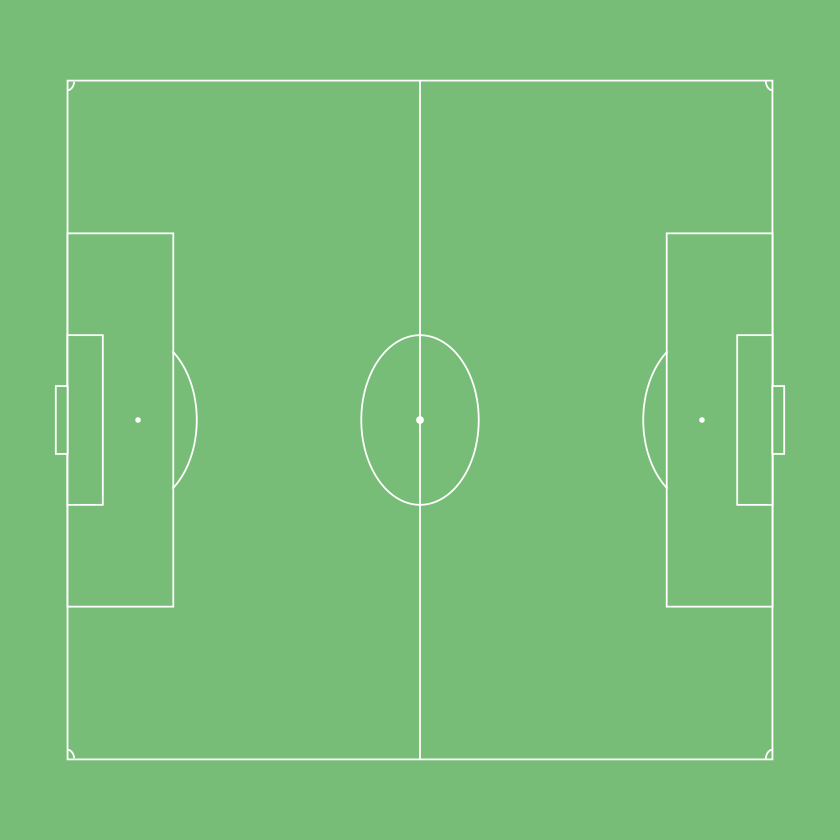

In [6]:
pitch()

<a id='analysis'></a>
<h1 style="color:forestgreen" >5. DATA ANALYSIS</h1>

<h2 style="color:forestgreen" >Lionel Messi vs Cristiano Ronaldo</h2>

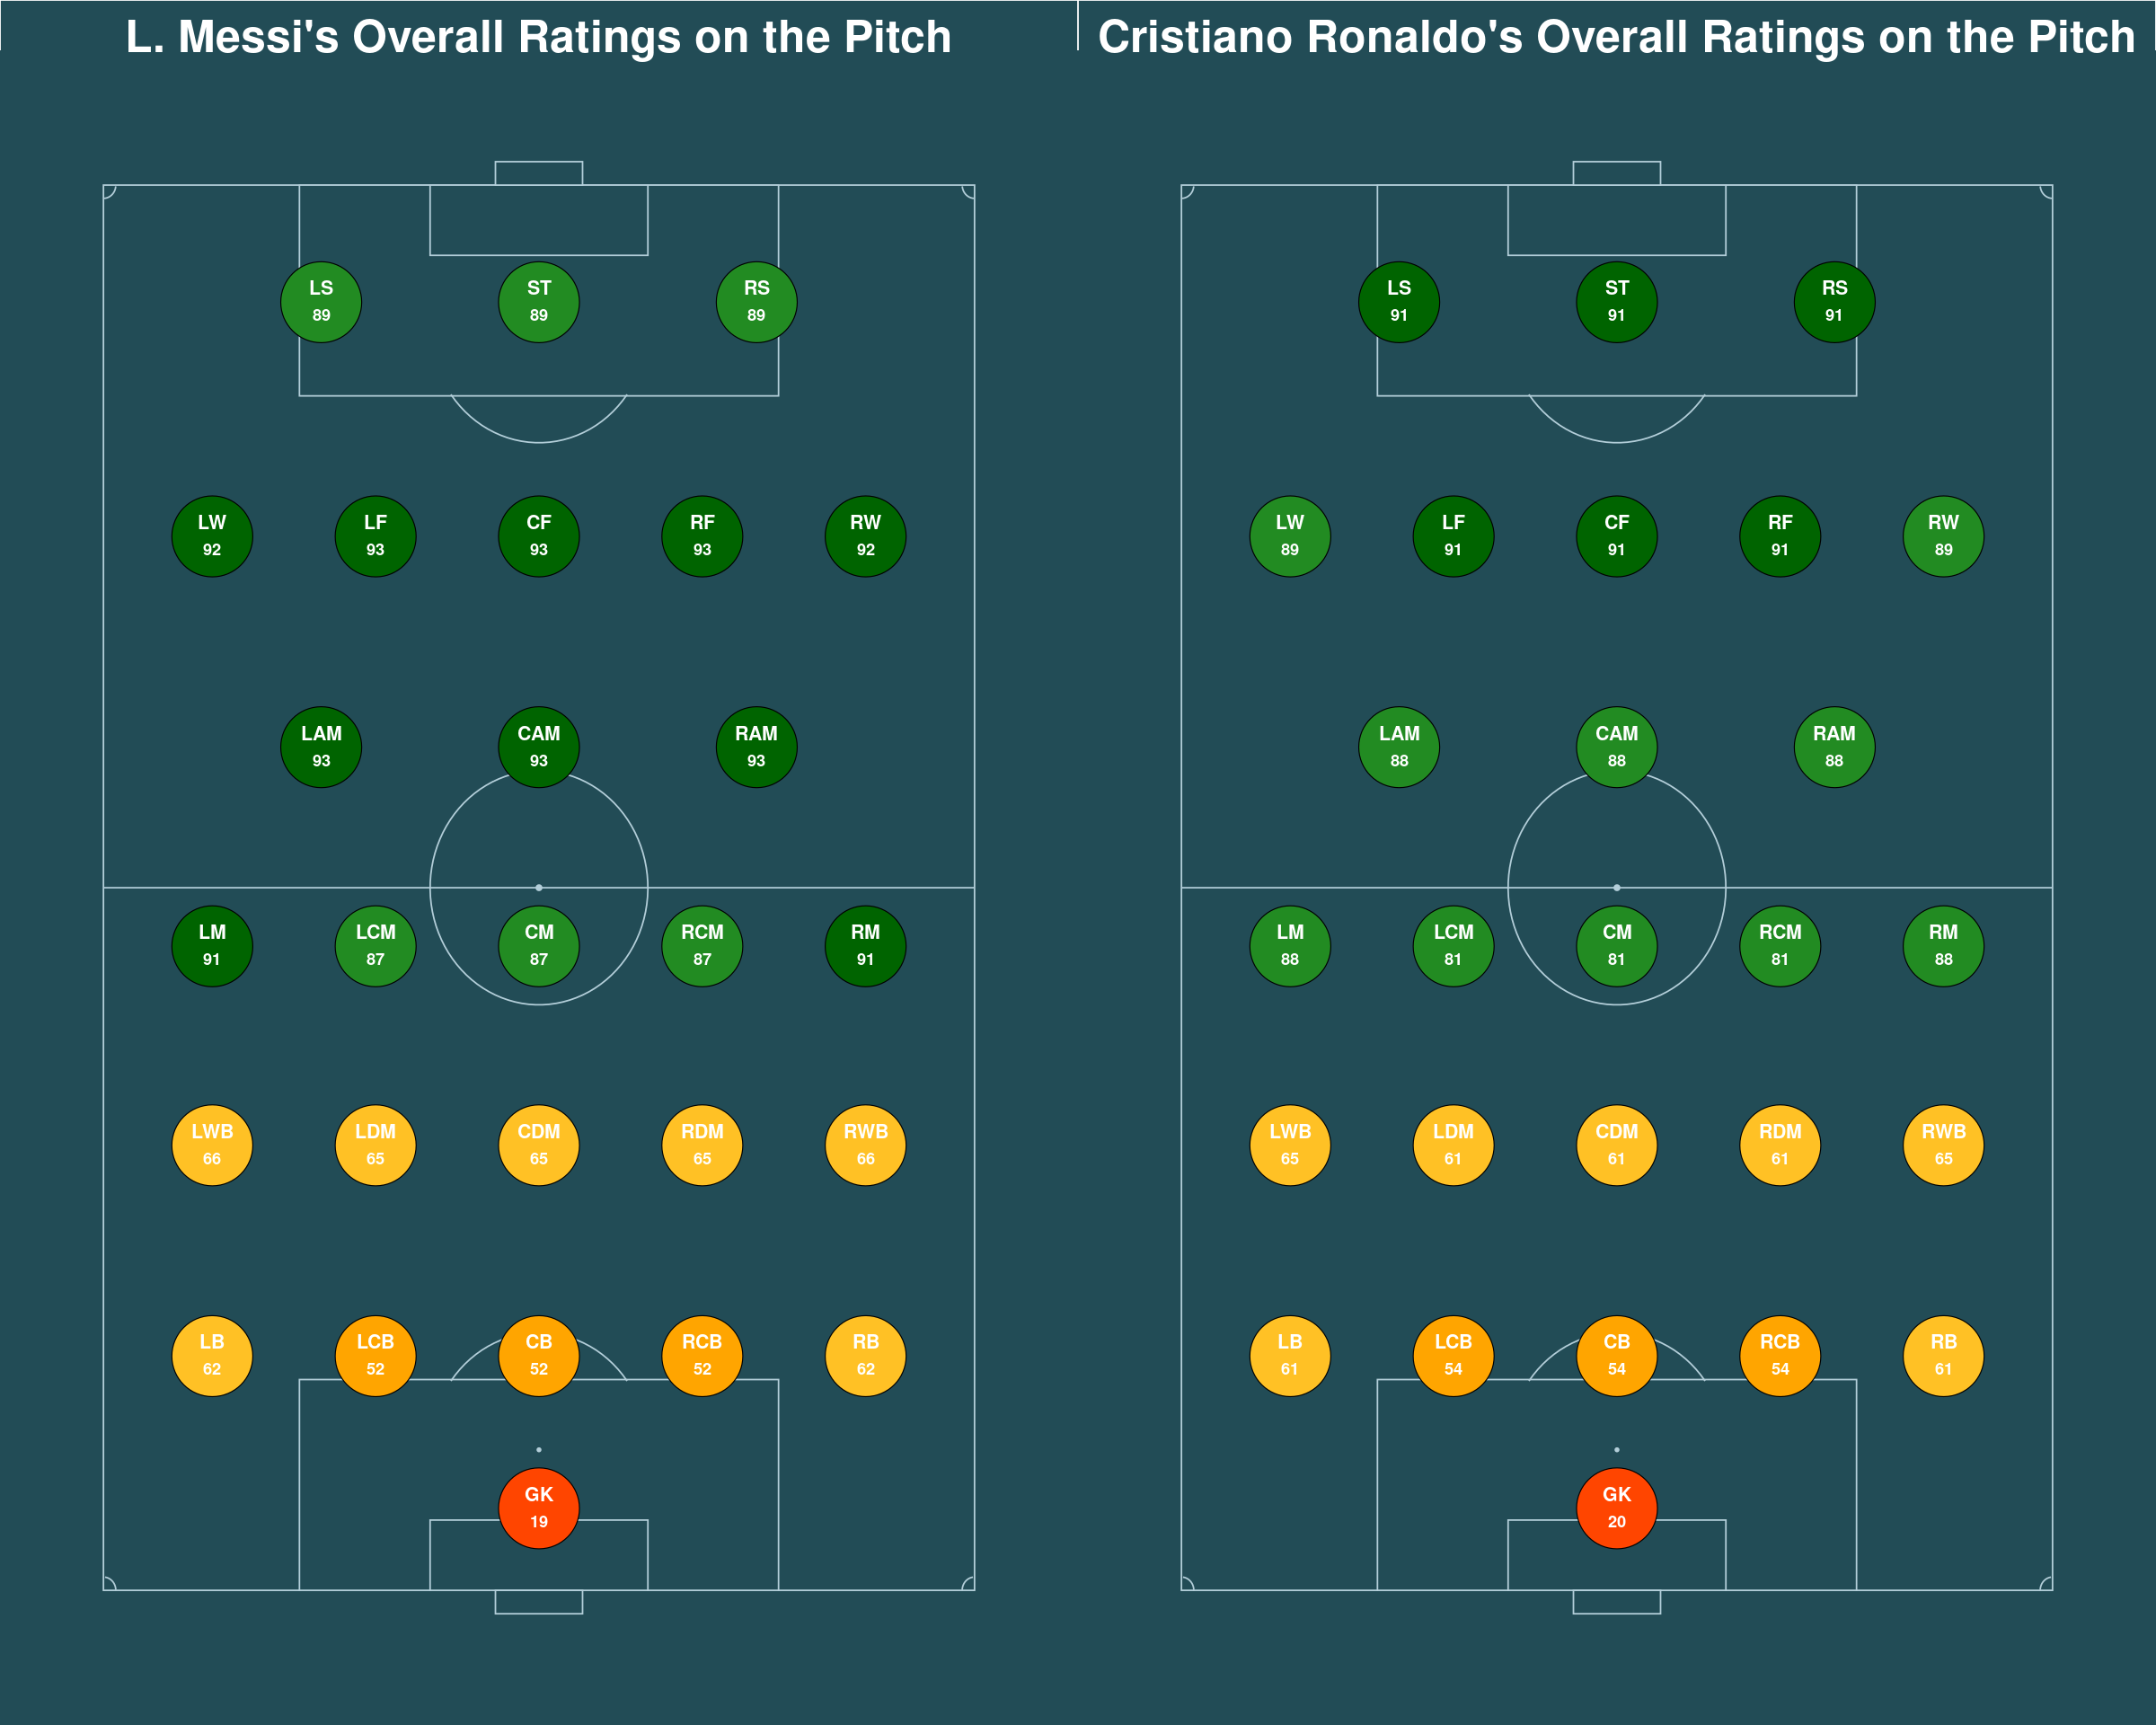

In [18]:
plot_player_ratings <- function(data, player_name)({

    player <- data%>%filter(Name == player_name)%>%select(Position, LS:GK)

    player <- suppressWarnings(as.data.frame(t(player)) %>%
      rownames_to_column("Pos") %>%
      filter(Pos != "Position")%>%
      mutate(V1 = as.numeric(str_sub(V1, end = 2)),
             Pos = as.character(Pos)))


    pos <- data.frame(
      Pos = as.character(c("GK","LB","LCB","CB", "RCB","RB",
                          "LWB", "LDM", "CDM", "RDM", "RWB",
                          "LM", "LCM", "CM", "RCM", "RM",
                          "LAM", "CAM", "RAM",
                          "LW","LF","CF","RF","RW",
                          "LS","ST","RS")),
      x = c(7, rep(20,5), rep(38, 5), rep(55, 5), rep(72, 3), rep(90,5), rep(110,3)),
      y = c(40,rep(c(10, 25, 40,55,70), 3), c(20, 40, 60),c(10, 25, 40, 55,70), c(20, 40, 60)))%>%suppressWarnings()%>%suppressMessages()


    player <- left_join(player, pos, by = 'Pos')%>%suppressWarnings()%>%suppressMessages()


    player <- na.omit(player)%>%suppressWarnings()%>%suppressMessages()


    p <- pitch(pitch_theme = "blue")+coord_flip()+
        geom_point(player, mapping = aes(x,y, fill = if_else(V1 < 50, "orangered",
                                        if_else(V1 <60, "orange",
                                                if_else(V1 < 70, "goldenrod1",
                                                        if_else(V1 <80, "palegreen4",
                                                                if_else(V1 < 90, "forestgreen",
                                                                        if_else(V1 == 0,
                                                                                "orangered","darkgreen"))))))), shape = 21, size = 25, show.legend = FALSE)+
    geom_text(player, mapping = aes(x,y, label = Pos), vjust= -0.5, color = "white", size = 4.5, fontface = "bold")+
    geom_text(player, mapping = aes(x,y, label = V1), vjust = 1.5, fontface = "bold", color = "white")+
    scale_fill_identity()+
    labs(title = paste0(player_name,"\'s Overall Ratings on the Pitch"))+
    theme(plot.title = element_text(hjust = 0.5,vjust = -1, size = 30, color = "white", face = "bold"))
    return(p)

})


options(repr.plot.width = 20, repr.plot.height = 16)
grid.arrange(
    ggdraw() +
      draw_plot(plot_player_ratings(df, "L. Messi")),
    ggdraw() +
      draw_plot(plot_player_ratings(df, "Cristiano Ronaldo")),
    ncol = 2
    )

Warning message:
“`funs()` was deprecated in dplyr 0.8.0.
ℹ Please use a list of either functions or lambdas:

# Simple named list: list(mean = mean, median = median)

# Auto named with `tibble::lst()`: tibble::lst(mean, median)

# Using lambdas list(~ mean(., trim = .2), ~ median(., na.rm = TRUE))”


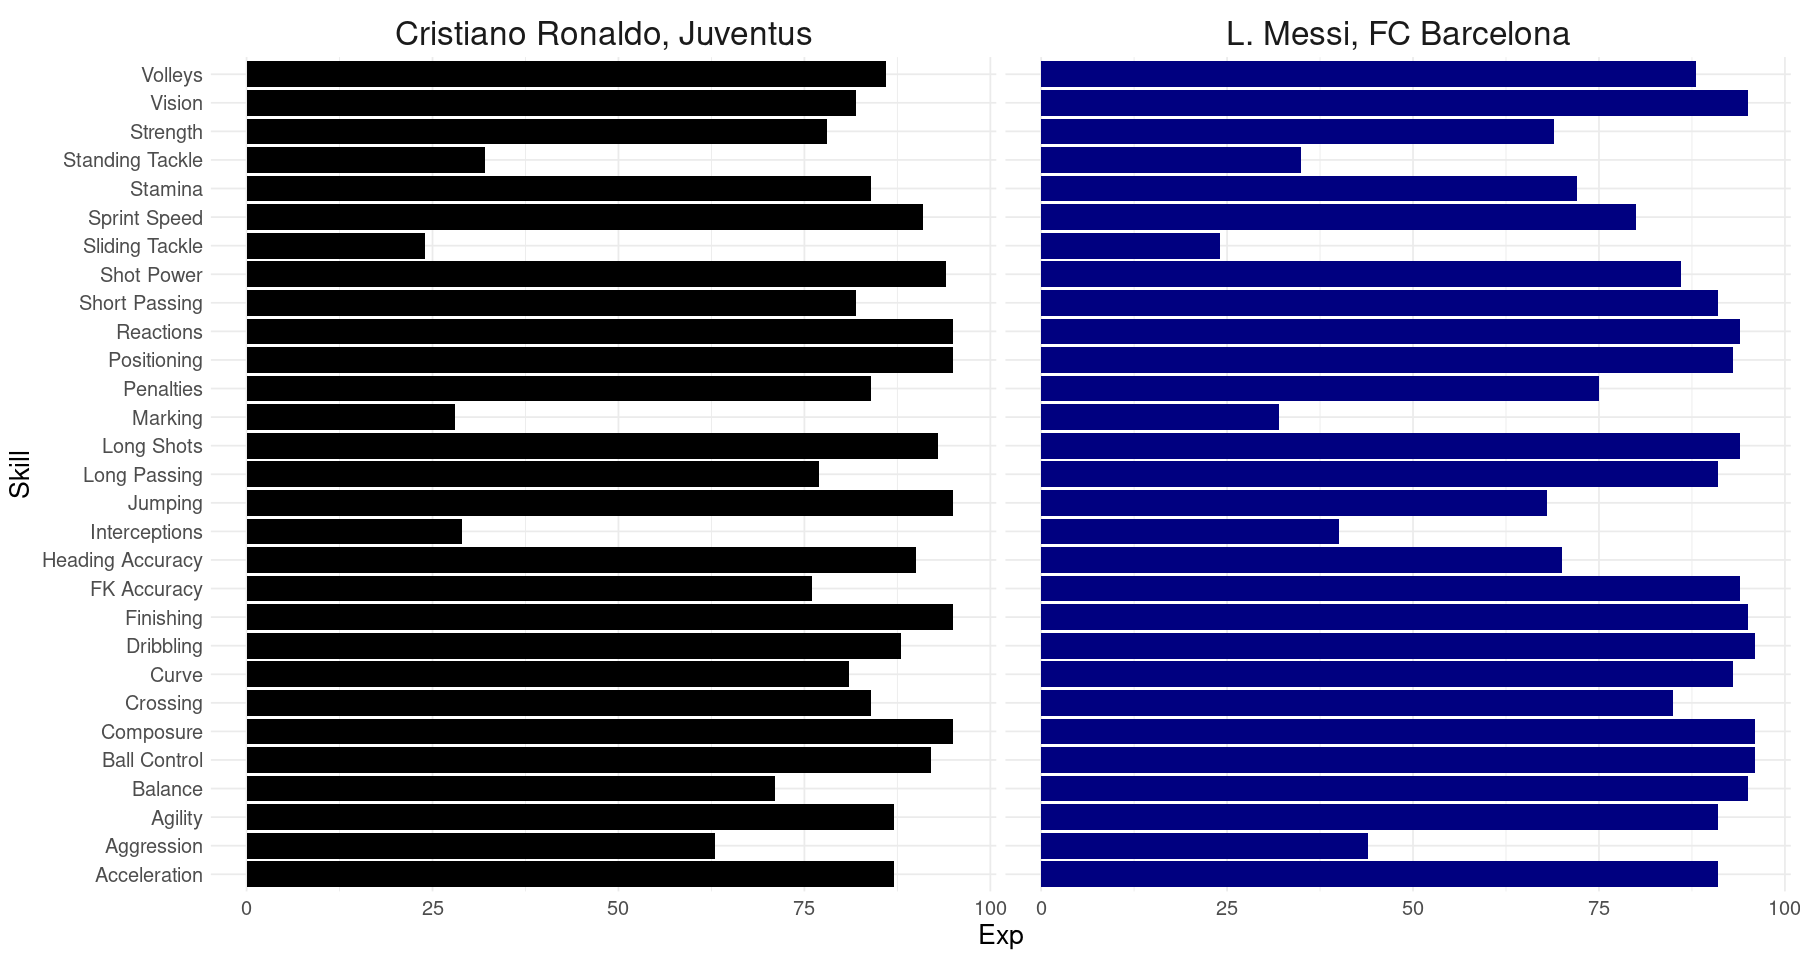

In [14]:
players <- df2 %>%
  filter(Name %in% c("Cristiano Ronaldo", "L. Messi")) %>%

  mutate(Name = paste0(Name, ", ", Club)) %>%

  select(Name,Crossing:Sliding.Tackle, -Mentality, -Power, -Defending, -Skill, -Movement ) %>%

  rename_all(funs(gsub("[[:punct:]]", " ", .))) %>%

  gather(Skill, Exp, Crossing:`Sliding Tackle`, -Name)


options(repr.plot.width = 15, repr.plot.height = 8)


ggplot(players, aes(Skill, Exp, fill = Name))+
  geom_col(show.legend = FALSE)+
  coord_flip()+
  facet_wrap(Name~.)+
  scale_fill_manual(values = c("black", "navy"))+
  theme_minimal()+
  theme(
      strip.text = element_text(size = 20),
      axis.title = element_text(size = 16),
      axis.text = element_text(size = 12)
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


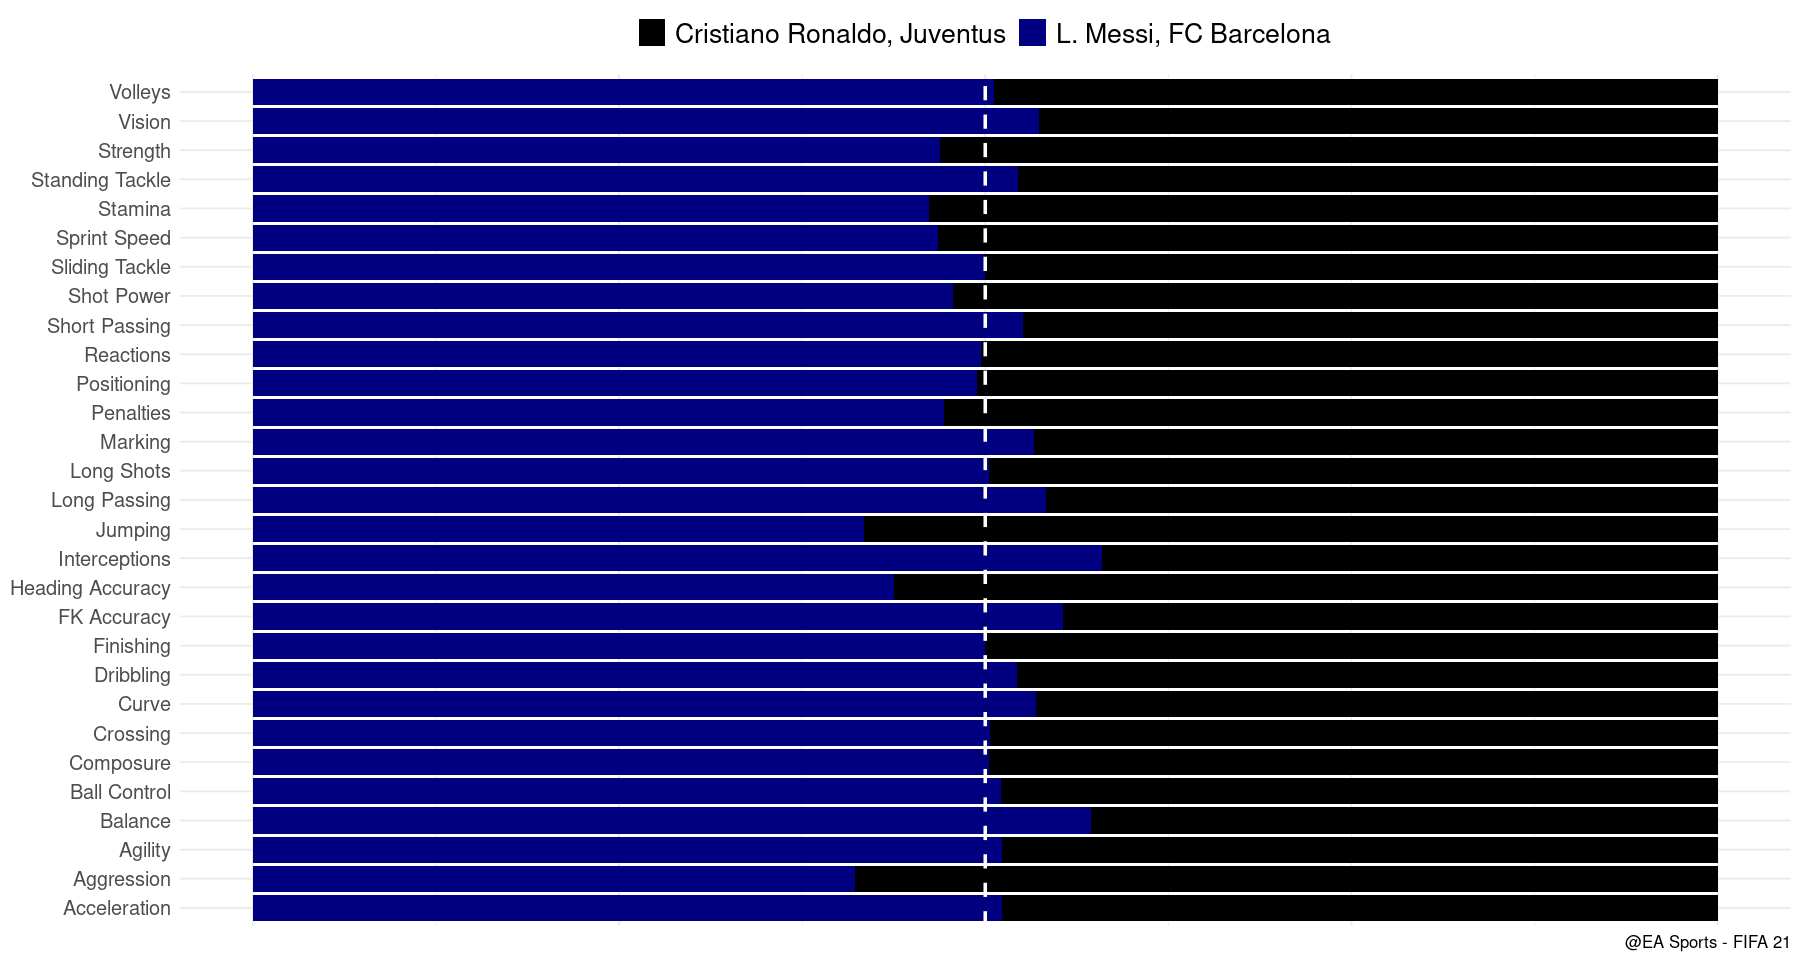

In [15]:
options(repr.plot.width = 15, repr.plot.height = 8)


ggplot(players, aes(Skill, Exp, fill = Name))+
  geom_col(position = "fill")+
  coord_flip()+
  scale_fill_manual(values = c("black", "navy"))+
  theme_minimal()+
  theme(
      strip.text = element_text(size = 20),
      axis.title = element_text(size = 16),
      axis.text = element_text(size = 12),
      legend.text = element_text(size = 16),
      plot.caption = element_text(size= 10)
  )+
  geom_hline(yintercept = 0.5, color = "white", size = 1, linetype = 2)+
  theme(legend.position = "top", axis.text.x=element_blank())+
  labs(caption = "@EA Sports - FIFA 21",
       fill = NULL,x = NULL, y = NULL)

<h2 style="color:forestgreen" >Dream Team</h2>

Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.sofifa.net]:
The requested URL returned error: 404”
Warning message in value[[3L]](cond):
“Error in prepare_image: HTTP response code said error [cdn.so

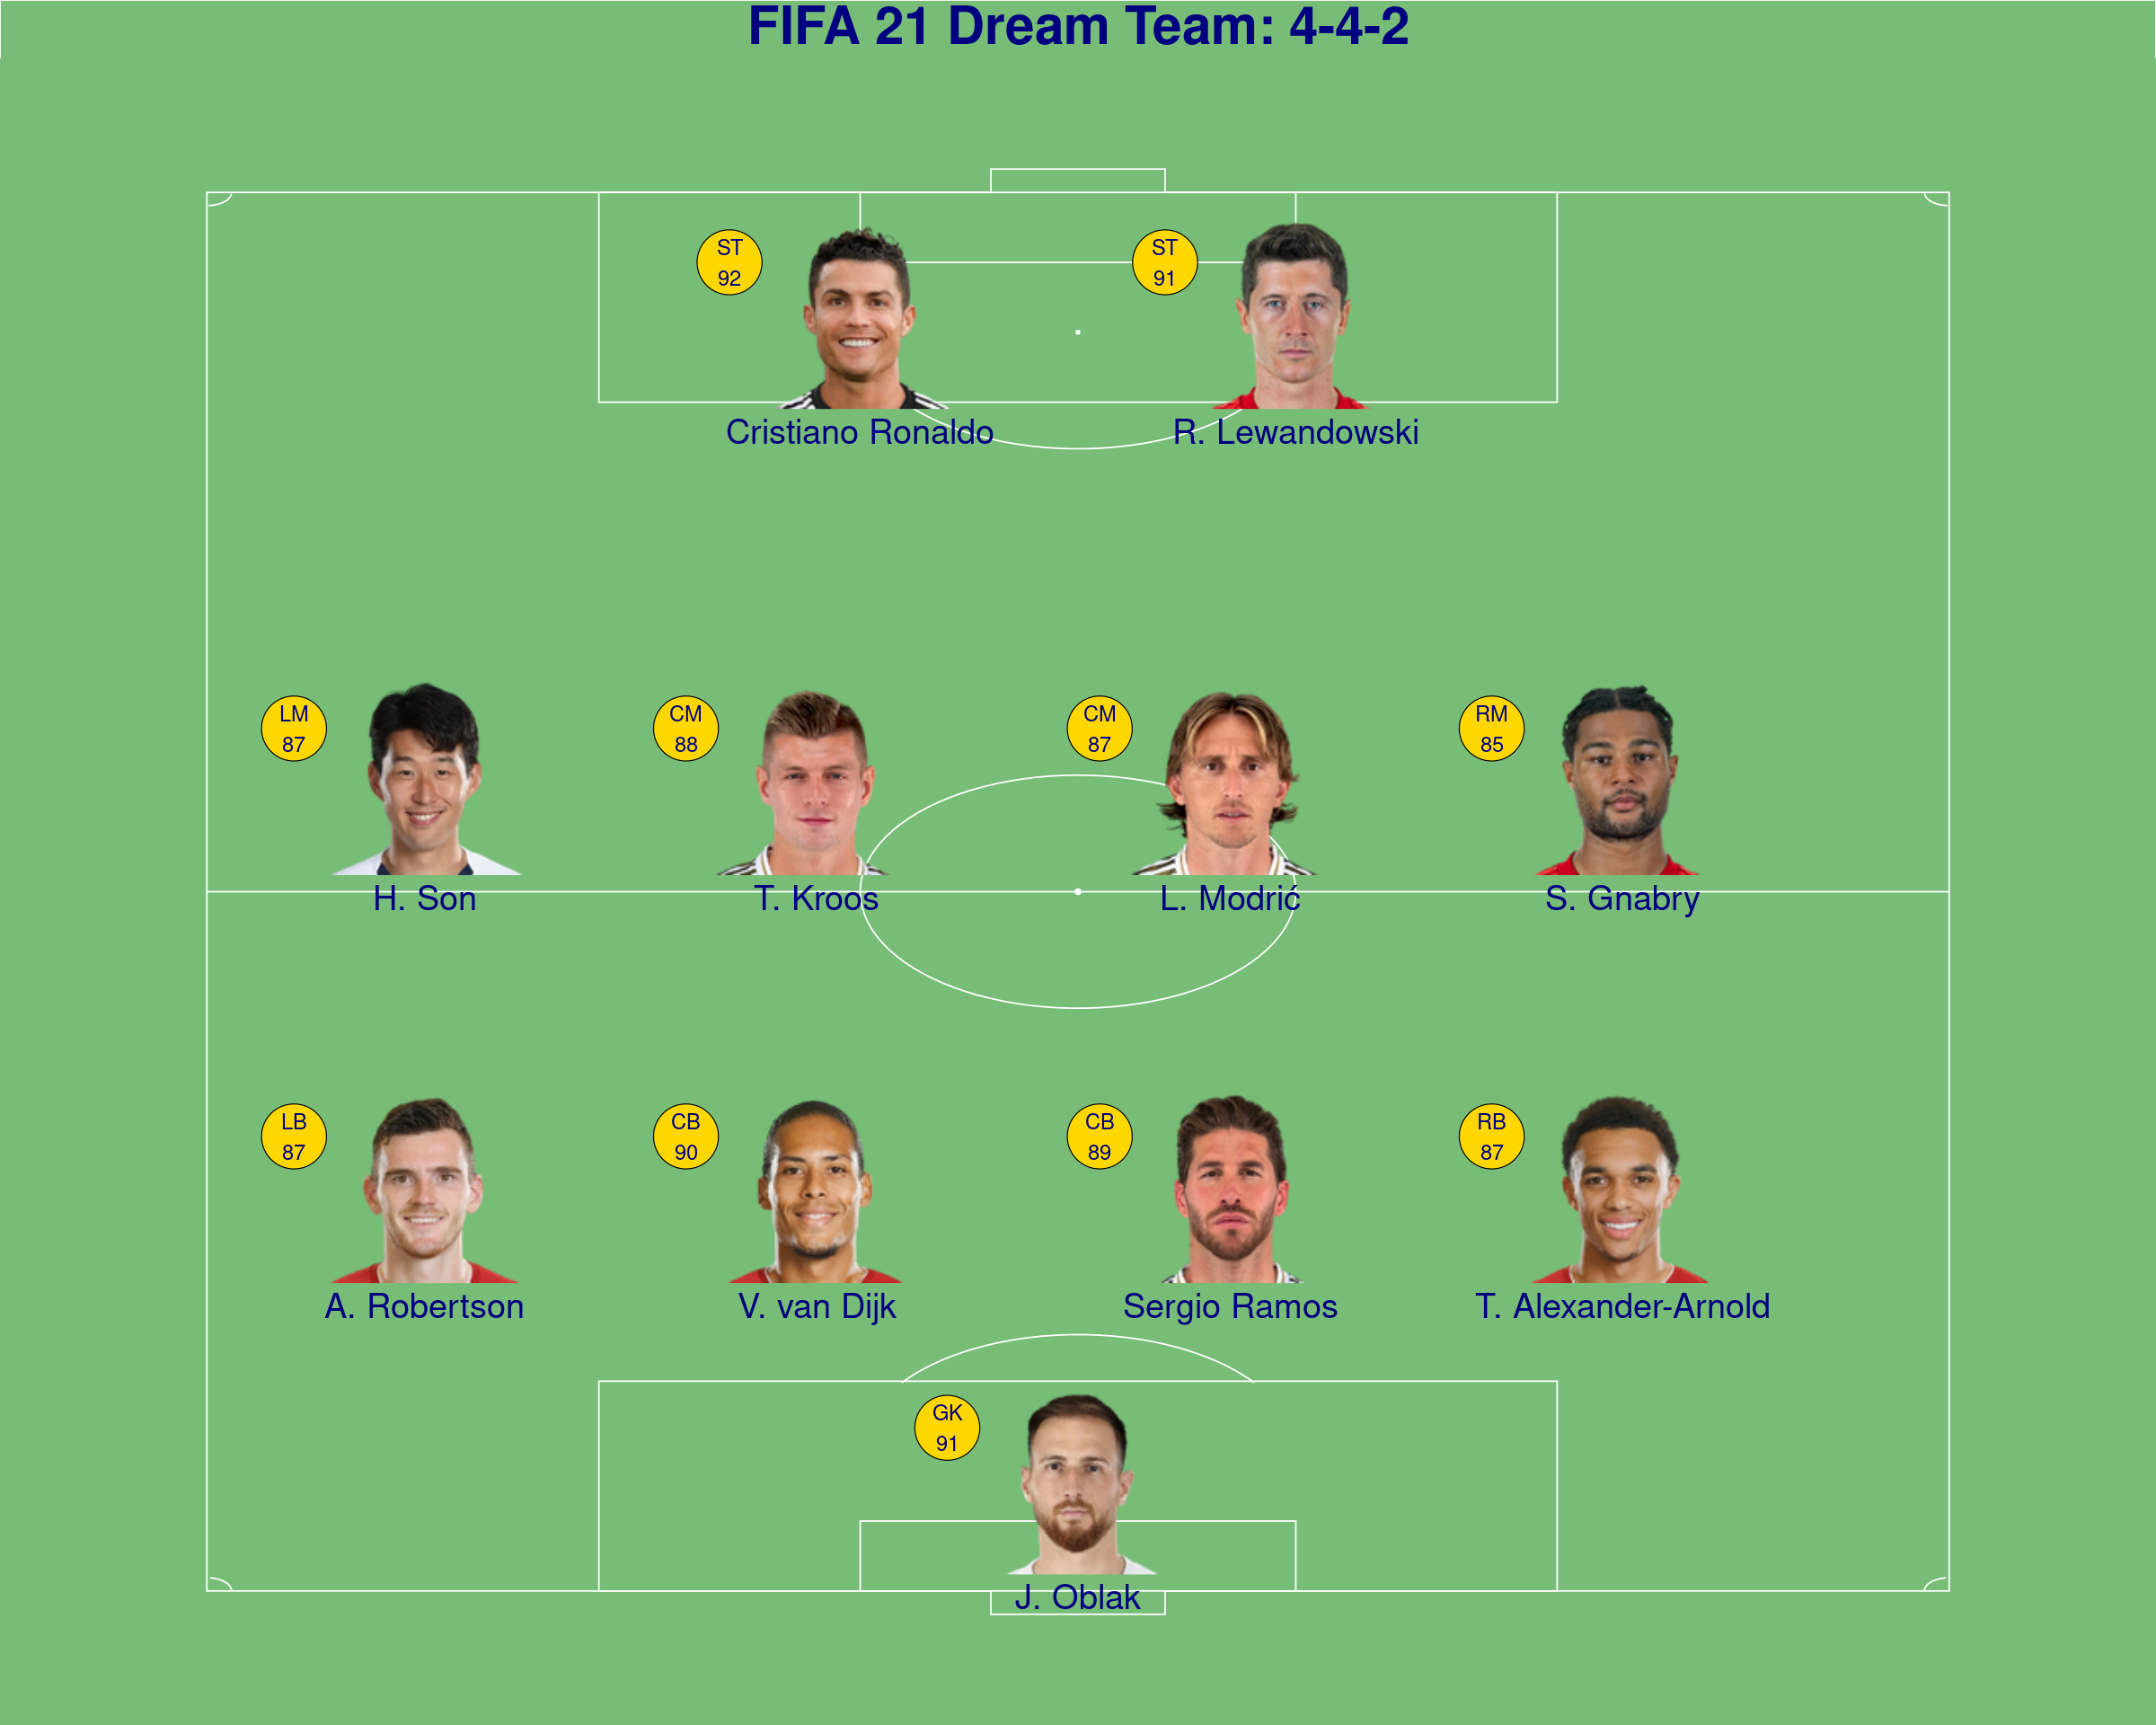

In [20]:
best_team <- function(df, input){

  team <- NULL

  if(missing("df") | missing("input")) return(res)
  if(is.null(df) | is.null(input)) return(res)

  team <- tibble()
  team_copy <- df %>% arrange(-OVA)

  tac442 <- c("GK","RB", "CB", "CB", "LB", "RM", "CM", "CM", "LM", "ST", "ST")
  tac352 <- c("GK","CB", "CB", "CB", "RM", "CM", "CM", "CM", "LM", "ST", "ST")
  tac433 <- c("GK", "LB", "CB","CB", "RB", "RM", "CM", "LM", "LW", "ST", "RW")

  tactic <- if(input == "4-4-2"){
    tac442
  }else if(input == "3-5-2"){
    tac352
  }else{
    tac433
  }

  for (i in tactic) {
      team %<>%  bind_rows(team_copy %>% filter(BP %in% i) %>% head(1))
      team_copy %<>% filter(!Name %in% (team %>% pull(Name)))

  }

  return(team)

}
tac442 <- best_team(df, input = "4-4-2")
tac433 <- best_team(df, input = "4-3-3")
tac352 <- best_team(df, input = "3-5-2")


tac442 <- tac442 %>%
    mutate(
        x = c(10, 35, 35, 35, 35, 70, 70, 70, 70, 110, 110),
        y = c(40, 65, 28, 47, 10, 65, 28,47,10, 30,50)
    )
p <- pitch(pitch_theme = "green")+
    coord_flip()+
    geom_image(tac442, mapping = aes(x, y, image = Player.Photo),size = 0.12)+
    geom_text(tac442, mapping = aes(x-10.5,y, label = Name),size = 8, color = "navy")+
    geom_image(tac442, mapping = aes(x, y, image = Club.Logo), size = 0.05,nudge_x = -17)+
    geom_point(tac442, mapping = aes(x+4, y-6), shape = 21, size = 20, fill = "gold")+
    geom_text(tac442, mapping = aes(x+4, y-6, label = paste0(BP, "\n", OVA) ),size = 5, color = "navy")+
    labs(title = "FIFA 21 Dream Team: 4-4-2")+
    theme(plot.title = element_text(size = 35, face = "bold", hjust = 0.5, vjust = 0.5, color = "navy"))

ggdraw() +
    draw_plot(p)

<h2 style="color:forestgreen" >Which team should I choose?</h2>

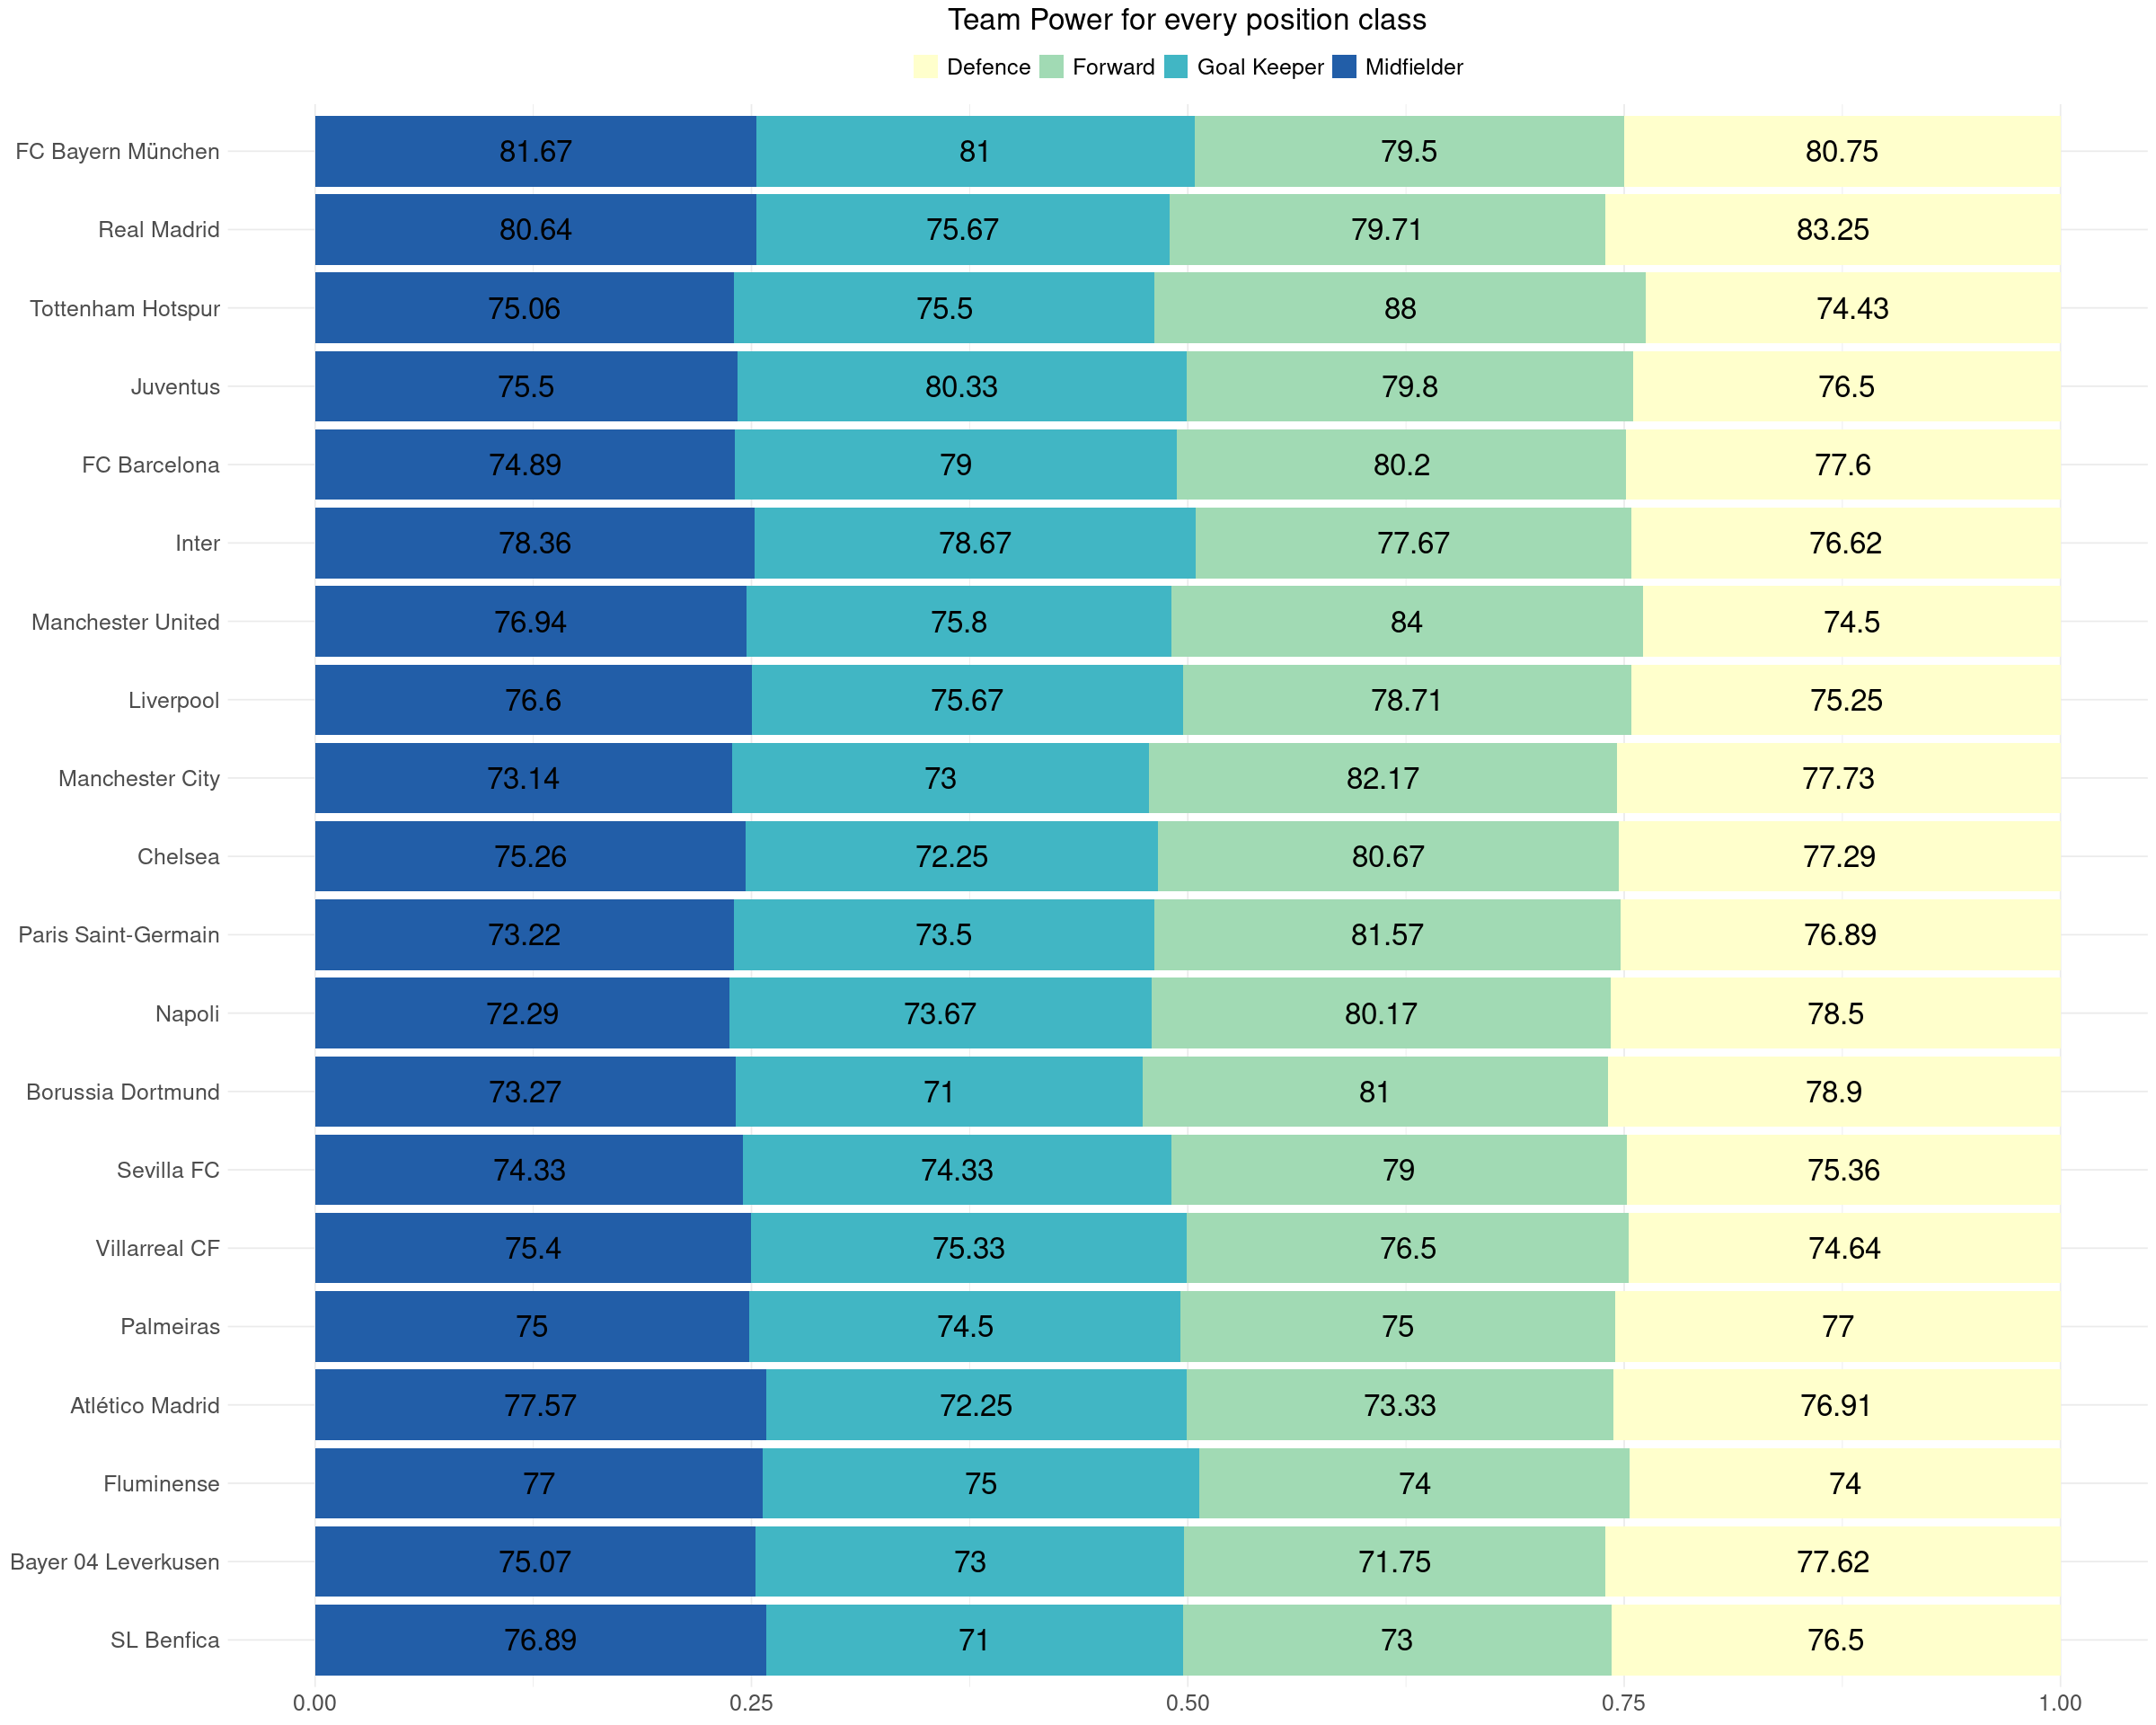

In [21]:
powerful <- suppressMessages(df2 %>%
  filter(!Club %in% Nationality, Club != "Zenit St. Petersburg")%>%
  group_by(Club) %>%
  summarise(mean = mean(OVA))) %>%
  arrange(-mean) %>%
  head(20)


suppressMessages(df2 %>%
  group_by(Club, Class) %>%
  summarise(mean = mean(OVA)) %>%
  ungroup()) %>%
  filter(Club %in% powerful$Club) %>%
  ggplot(aes(reorder(Club, mean), mean, fill = Class))+
  geom_col(position = "fill")+
  geom_text(aes(label = round(mean,digits = 2)), position = position_fill(0.5), size = 7)+
  coord_flip()+
  theme_minimal()+
  theme(legend.position = "top", axis.text = element_text(size = 15), legend.text = element_text(size = 15),
       plot.title = element_text(hjust = 0.5, size = 20))+
  labs(x = NULL, y = NULL, fill = NULL,title = "Team Power for every position class")+
  scale_fill_brewer(palette = 16)